# 🧠 Neural Text-to-SQL: GNN Schema Understanding

This notebook implements a **Graph Neural Network** to understand database schema relationships.

## Pipeline:
1. Load schema metadata (tables, columns, foreign keys)
2. Build a heterogeneous graph (tables = nodes, FK = edges)
3. Train a **GraphSAGE** model to produce schema embeddings
4. Export embeddings + helper functions for the FastAPI backend

---

In [23]:
import torch
print(torch.__version__)

2.10.0+cpu


In [24]:
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.2.0+cu118.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.2.0+cu118.html
!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.2.0+cu118.html
Looking in links: https://data.pyg.org/whl/torch-2.2.0+cu118.html


In [25]:
import json
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, HeteroData
from torch_geometric.nn import SAGEConv, GATConv
from torch_geometric.utils import from_networkx

from sentence_transformers import SentenceTransformer

# Install dependencies if needed
!pip install torch torch-geometric networkx sentence-transformers matplotlib numpy

print(f'PyTorch: {torch.__version__}')
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')

PyTorch: 2.10.0+cpu
Device: cpu


## 1. Load Schema Metadata

In [26]:
METADATA_PATH = '/content/schema_metadata.json'
OUTPUT_DIR = '/content/data'

with open(METADATA_PATH) as f:
    metadata = json.load(f)

print(f'Loaded {len(metadata["schemas"])} schemas:')
for schema_name, schema in metadata['schemas'].items():
    print(f'  {schema_name}: {len(schema["tables"])} tables')

Loaded 3 schemas:
  ecommerce: 6 tables
  finance: 6 tables
  healthcare: 6 tables


## 2. Build Schema Graph with NetworkX

In [27]:
def build_schema_graph(schema_name: str, schema_data: dict) -> nx.DiGraph:
    """
    Build a directed graph where:
    - Nodes: tables AND individual columns
    - Edges: table→column (has_column), FK (references)
    """
    G = nx.DiGraph()
    tables = schema_data['tables']

    # Add table nodes
    for table_name, table_info in tables.items():
        node_id = f'{schema_name}.{table_name}'
        G.add_node(node_id,
                   node_type='table',
                   schema=schema_name,
                   name=table_name,
                   description=table_info.get('description', ''))

        # Add column nodes
        for col in table_info['columns']:
            col_id = f'{schema_name}.{table_name}.{col}'
            G.add_node(col_id,
                       node_type='column',
                       schema=schema_name,
                       table=table_name,
                       name=col,
                       description=f'{col} column of {table_name}')
            # table → column edge
            G.add_edge(node_id, col_id, edge_type='has_column')

    # Add FK edges
    for rel in schema_data.get('relationships', []):
        from_node = f'{schema_name}.{rel["from"]}'
        to_node = f'{schema_name}.{rel["to"]}'
        if G.has_node(from_node) and G.has_node(to_node):
            G.add_edge(from_node, to_node, edge_type='references')
            G.add_edge(to_node, from_node, edge_type='referenced_by')

    return G


# Build graphs for all schemas
schema_graphs = {}
for schema_name, schema_data in metadata['schemas'].items():
    G = build_schema_graph(schema_name, schema_data)
    schema_graphs[schema_name] = G
    print(f'{schema_name}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

ecommerce: 47 nodes, 53 edges
finance: 49 nodes, 53 edges
healthcare: 51 nodes, 55 edges


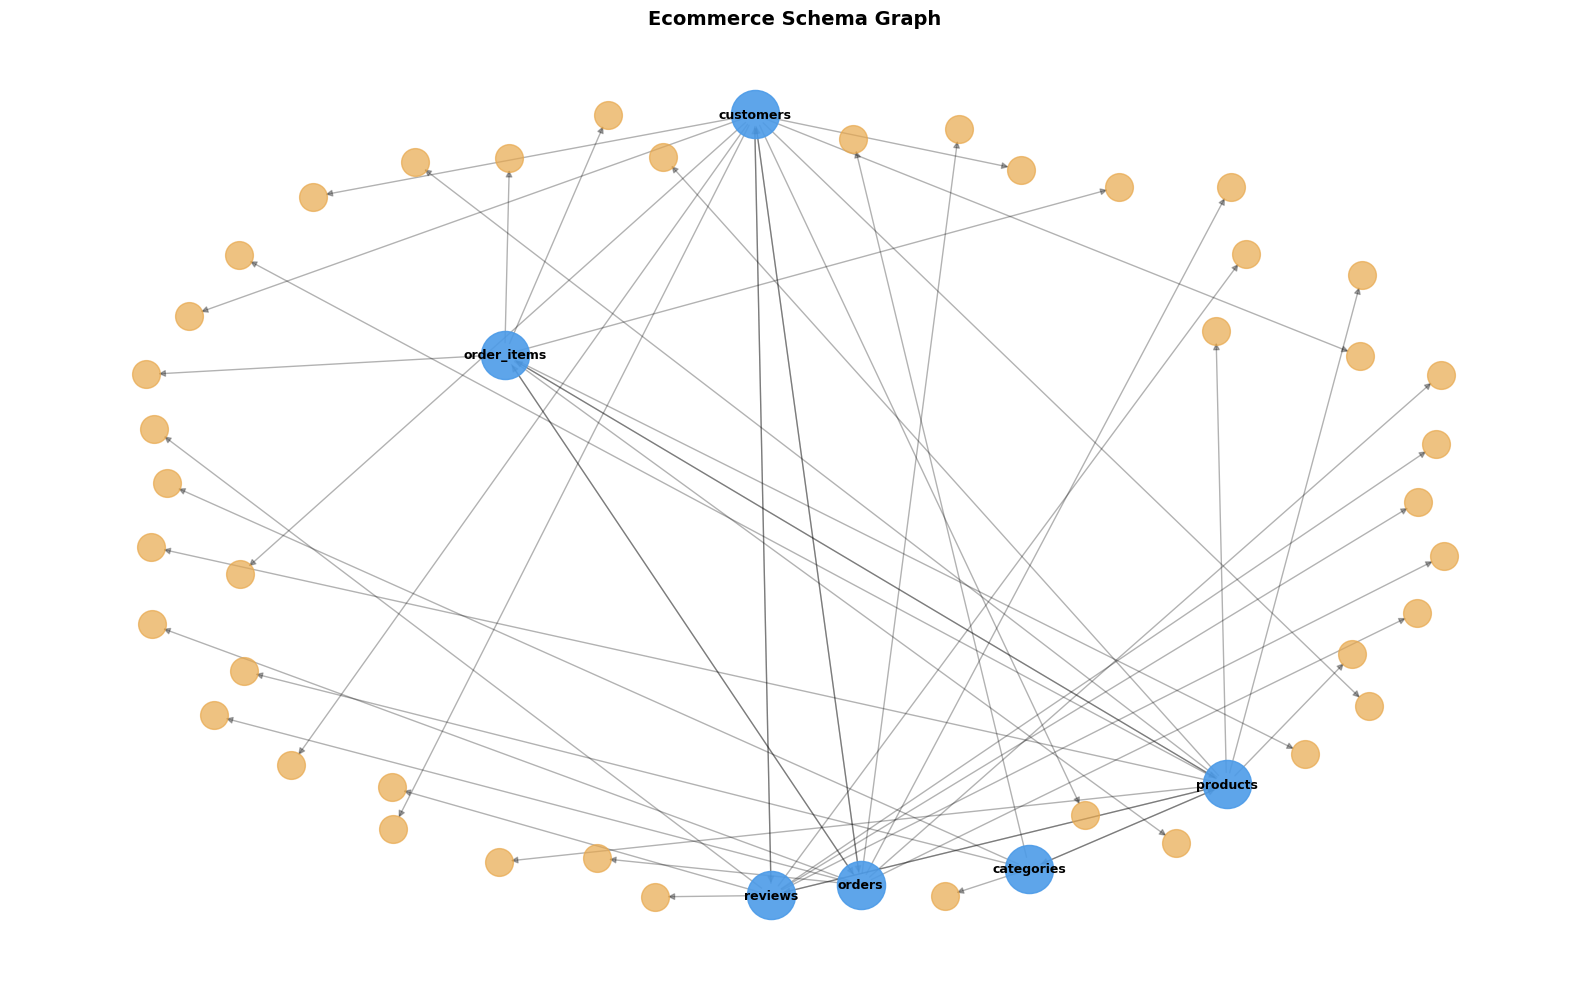

Saved: ecommerce_graph.png


In [28]:
# Visualize ecommerce schema graph
def visualize_schema_graph(G, title, schema_name):
    plt.figure(figsize=(16, 10))

    # Separate table vs column nodes
    table_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'table']
    col_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'column']

    pos = nx.spring_layout(G, k=3, seed=42)

    nx.draw_networkx_nodes(G, pos, nodelist=table_nodes,
                           node_color='#4C9BE8', node_size=1200, alpha=0.9)
    nx.draw_networkx_nodes(G, pos, nodelist=col_nodes,
                           node_color='#E8A84C', node_size=400, alpha=0.7)
    nx.draw_networkx_edges(G, pos, alpha=0.3, arrows=True, arrowsize=10)

    # Only label table nodes
    labels = {n: n.split('.')[-1] for n in table_nodes}
    nx.draw_networkx_labels(G, pos, labels, font_size=9, font_weight='bold')

    plt.title(f'{title} Schema Graph', fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    # Create the output directory if it doesn't exist
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    plt.savefig(f'{OUTPUT_DIR}/{schema_name}_graph.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {schema_name}_graph.png')

visualize_schema_graph(schema_graphs['ecommerce'], 'Ecommerce', 'ecommerce')

## 3. Generate Node Features with Sentence Transformers

In [29]:
# Load sentence transformer for semantic embeddings of node descriptions
print('Loading Sentence Transformer model...')
st_model = SentenceTransformer('all-MiniLM-L6-v2')  # lightweight 384-dim model
print('Model loaded!')

Loading Sentence Transformer model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!


In [30]:
def compute_node_features(G: nx.DiGraph, model: SentenceTransformer) -> torch.Tensor:
    """
    Encode each node's description string into a feature vector.
    Returns: FloatTensor [num_nodes, 384]
    """
    nodes = list(G.nodes(data=True))
    descriptions = []

    for node_id, attrs in nodes:
        ntype = attrs.get('node_type', 'unknown')
        name = attrs.get('name', '')
        desc = attrs.get('description', '')
        text = f"{ntype}: {name}. {desc}"
        descriptions.append(text)

    print(f'  Encoding {len(descriptions)} node descriptions...')
    embeddings = model.encode(descriptions, batch_size=64, show_progress_bar=True)
    return torch.FloatTensor(embeddings)


# Compute features for each schema
schema_node_features = {}
for schema_name, G in schema_graphs.items():
    print(f'\nComputing features for {schema_name}...')
    feats = compute_node_features(G, st_model)
    schema_node_features[schema_name] = feats
    print(f'  Feature shape: {feats.shape}')


Computing features for ecommerce...
  Encoding 47 node descriptions...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

  Feature shape: torch.Size([47, 384])

Computing features for finance...
  Encoding 49 node descriptions...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

  Feature shape: torch.Size([49, 384])

Computing features for healthcare...
  Encoding 51 node descriptions...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

  Feature shape: torch.Size([51, 384])


## 4. Convert NetworkX Graph to PyTorch Geometric Data

In [31]:
def nx_to_pyg(G: nx.DiGraph, node_features: torch.Tensor) -> Data:
    """
    Convert NetworkX graph + features to PyTorch Geometric Data object.
    """
    node_list = list(G.nodes())
    node_idx = {n: i for i, n in enumerate(node_list)}

    edge_index_list = []
    for src, dst in G.edges():
        edge_index_list.append([node_idx[src], node_idx[dst]])

    if edge_index_list:
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
    else:
        edge_index = torch.zeros((2, 0), dtype=torch.long)

    # Node type mask: 1 for table, 0 for column
    node_types = []
    for n in node_list:
        ntype = G.nodes[n].get('node_type', 'column')
        node_types.append(1 if ntype == 'table' else 0)

    data = Data(
        x=node_features,
        edge_index=edge_index,
        num_nodes=len(node_list),
        node_type=torch.tensor(node_types, dtype=torch.long),
    )
    data.node_names = node_list
    return data


pyg_data = {}
for schema_name, G in schema_graphs.items():
    data = nx_to_pyg(G, schema_node_features[schema_name])
    pyg_data[schema_name] = data
    print(f'{schema_name}: nodes={data.num_nodes}, edges={data.edge_index.shape[1]}')

ecommerce: nodes=47, edges=53
finance: nodes=49, edges=53
healthcare: nodes=51, edges=55


## 5. Define GraphSAGE Model

In [32]:
class SchemaGraphSAGE(nn.Module):
    """
    2-layer GraphSAGE encoder for schema understanding.
    Input: Node features from Sentence Transformer (384-dim)
    Output: Schema embeddings (128-dim)
    """
    def __init__(self, in_channels=384, hidden_channels=256, out_channels=128):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.dropout = nn.Dropout(0.3)
        self.bn1 = nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def get_embeddings(self, x, edge_index):
        with torch.no_grad():
            return self.forward(x, edge_index)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = SchemaGraphSAGE().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Using device: cpu
SchemaGraphSAGE(
  (conv1): SAGEConv(384, 256, aggr=mean)
  (conv2): SAGEConv(256, 128, aggr=mean)
  (dropout): Dropout(p=0.3, inplace=False)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)
Total parameters: 263,040


## 6. Self-Supervised Pre-training (Link Prediction)

In [33]:
from torch_geometric.utils import negative_sampling

def link_prediction_loss(z, pos_edge_index, neg_edge_index):
    """Binary cross-entropy loss for link prediction."""
    EPS = 1e-15

    pos_score = (z[pos_edge_index[0]] * z[pos_edge_index[1]]).sum(dim=-1)
    neg_score = (z[neg_edge_index[0]] * z[neg_edge_index[1]]).sum(dim=-1)

    pos_loss = -torch.log(torch.sigmoid(pos_score) + EPS).mean()
    neg_loss = -torch.log(1 - torch.sigmoid(neg_score) + EPS).mean()
    return pos_loss + neg_loss


def train_on_schema(model, data, epochs=100, lr=0.001):
    """Train GraphSAGE on a single schema graph."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    x = data.x.to(device)
    edge_index = data.edge_index.to(device)

    model.train()
    losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        z = model(x, edge_index)

        # Generate negative edges for contrastive learning
        neg_edge_index = negative_sampling(
            edge_index=edge_index,
            num_nodes=data.num_nodes,
            num_neg_samples=edge_index.size(1)
        )

        loss = link_prediction_loss(z, edge_index, neg_edge_index)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if (epoch + 1) % 20 == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs} | Loss: {loss.item():.4f}')

    return losses


print('Training GraphSAGE on all schemas...')
all_losses = {}
for schema_name, data in pyg_data.items():
    print(f'\n--- Schema: {schema_name} ---')
    losses = train_on_schema(model, data, epochs=100)
    all_losses[schema_name] = losses

Training GraphSAGE on all schemas...

--- Schema: ecommerce ---
  Epoch  20/100 | Loss: 6.5268
  Epoch  40/100 | Loss: 9.7689
  Epoch  60/100 | Loss: 6.0989
  Epoch  80/100 | Loss: 2.7795
  Epoch 100/100 | Loss: 2.6532

--- Schema: finance ---
  Epoch  20/100 | Loss: 2.3919
  Epoch  40/100 | Loss: 2.8046
  Epoch  60/100 | Loss: 2.8517
  Epoch  80/100 | Loss: 2.6977
  Epoch 100/100 | Loss: 3.4555

--- Schema: healthcare ---
  Epoch  20/100 | Loss: 2.3367
  Epoch  40/100 | Loss: 3.8061
  Epoch  60/100 | Loss: 2.0117
  Epoch  80/100 | Loss: 3.7131
  Epoch 100/100 | Loss: 3.6933


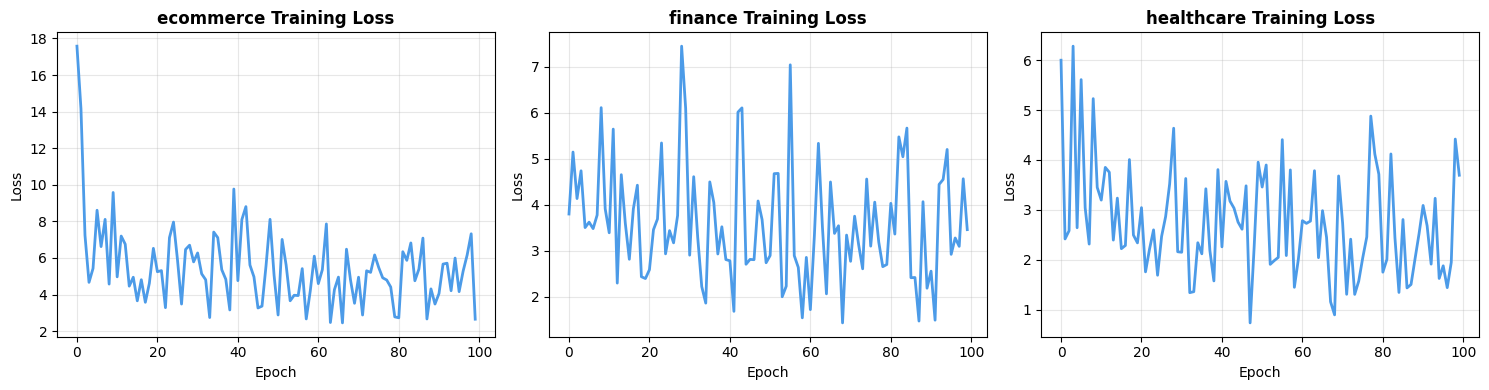

In [34]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (schema_name, losses) in zip(axes, all_losses.items()):
    ax.plot(losses, linewidth=2, color='#4C9BE8')
    ax.set_title(f'{schema_name} Training Loss', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150)
plt.show()

## 7. Extract and Save Schema Embeddings

In [35]:
model.eval()

schema_embeddings = {}  # schema_name -> {node_name: embedding_vector}

for schema_name, data in pyg_data.items():
    x = data.x.to(device)
    edge_index = data.edge_index.to(device)

    with torch.no_grad():
        z = model(x, edge_index)

    emb_np = z.cpu().numpy()
    node_embeddings = {}

    for i, node_name in enumerate(data.node_names):
        node_embeddings[node_name] = emb_np[i].tolist()

    schema_embeddings[schema_name] = node_embeddings
    print(f'{schema_name}: {len(node_embeddings)} node embeddings (dim=128)')

# Save embeddings
emb_path = f'{OUTPUT_DIR}/schema_embeddings.json'
with open(emb_path, 'w') as f:
    json.dump(schema_embeddings, f)
print(f'\n✅ Embeddings saved to: {emb_path}')

# Save model weights
model_path = f'{OUTPUT_DIR}/gnn_model.pt'
torch.save(model.state_dict(), model_path)
print(f'✅ Model saved to: {model_path}')

ecommerce: 47 node embeddings (dim=128)
finance: 49 node embeddings (dim=128)
healthcare: 51 node embeddings (dim=128)

✅ Embeddings saved to: /content/data/schema_embeddings.json
✅ Model saved to: /content/data/gnn_model.pt


## 8. Table Relevance Function
Given a natural language query, find the most relevant tables using embedding similarity.

In [36]:
from sklearn.metrics.pairwise import cosine_similarity
import torch.nn as nn # Ensure nn is imported for nn.Linear

def get_relevant_tables(query: str, schema_name: str, top_k: int = 3) -> list:
    """
    Find the top-k most relevant tables for a given natural language query.

    Args:
        query: Natural language query string
        schema_name: Which schema to search ('ecommerce', 'finance', 'healthcare')
        top_k: Number of tables to return

    Returns:
        List of (table_name, similarity_score) tuples
    """
    # Encode the query using Sentence Transformer
    query_st_emb = st_model.encode([query])  # shape: (1, 384)

    # Project the query embedding from 384 dimensions to 128 dimensions
    # to match the GNN-generated schema embeddings.
    # NOTE: This linear projection layer is initialized randomly and is NOT trained.
    # For a production system, this projection layer should be part of a trained
    # dual encoder or a more sophisticated query encoding mechanism to ensure
    # semantic alignment between queries and GNN embeddings.
    query_projection_layer = nn.Linear(query_st_emb.shape[1], 128)
    query_emb = query_projection_layer(torch.tensor(query_st_emb, dtype=torch.float32)).detach().numpy()

    G = schema_graphs[schema_name]
    embeddings = schema_embeddings[schema_name]

    table_scores = []
    for node_name, node_emb in embeddings.items():
        # Only consider table nodes
        if G.nodes[node_name].get('node_type') != 'table':
            continue

        sim = cosine_similarity(query_emb, [node_emb])[0][0]
        table_name = node_name.split('.')[-1]  # Extract just table name
        table_scores.append((table_name, float(sim)))

    # Sort by similarity descending
    table_scores.sort(key=lambda x: x[1], reverse=True)
    return table_scores[:top_k]


# Test the function
test_queries = [
    ("Show me total revenue by product category", "ecommerce"),
    ("Which customers have the highest credit scores?", "finance"),
    ("List doctors with most appointments this month", "healthcare"),
]

print('=== Table Relevance Results ===')
for query, schema in test_queries:
    results = get_relevant_tables(query, schema, top_k=3)
    print(f'\nQuery: "{query}"')
    print(f'Schema: {schema}')
    for table, score in results:
        print(f'  {table:20s} score={score:.4f}')

=== Table Relevance Results ===

Query: "Show me total revenue by product category"
Schema: ecommerce
  orders               score=0.1968
  order_items          score=0.1245
  categories           score=0.0144

Query: "Which customers have the highest credit scores?"
Schema: finance
  customers            score=0.0953
  loans                score=0.0761
  transactions         score=0.0659

Query: "List doctors with most appointments this month"
Schema: healthcare
  prescriptions        score=0.0908
  doctors              score=0.0390
  billing              score=0.0366


## 9. Export Helper Functions for Backend

In [37]:
# Save the complete GNN inference package for backend use
gnn_package = {
    'schema_embeddings': schema_embeddings,
    'schema_node_types': {},  # node_name -> 'table' or 'column'
    'schema_table_columns': {},  # table_name -> [columns]
}

for schema_name, G in schema_graphs.items():
    gnn_package['schema_node_types'][schema_name] = {
        node: data.get('node_type', 'column')
        for node, data in G.nodes(data=True)
    }

# Extract table→column mapping
for schema_name, schema_data in metadata['schemas'].items():
    gnn_package['schema_table_columns'][schema_name] = {
        table: info['columns']
        for table, info in schema_data['tables'].items()
    }

pkg_path = f'{OUTPUT_DIR}/gnn_package.json'
with open(pkg_path, 'w') as f:
    json.dump(gnn_package, f)

print(f'✅ GNN package saved to: {pkg_path}')

# Also save sentence transformer query encoder
st_model.save(f'{OUTPUT_DIR}/sentence_transformer')
print(f'✅ Sentence transformer saved')

✅ GNN package saved to: /content/data/gnn_package.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Sentence transformer saved


In [38]:
# Final summary
print('=== GNN Training Complete ===')
print(f'Schemas processed: {list(schema_graphs.keys())}')
print(f'Total nodes: {sum(G.number_of_nodes() for G in schema_graphs.values())}')
print(f'Embedding dimension: 128')
print(f'\nOutput files:')
import os
for f in os.listdir(OUTPUT_DIR):
    path = os.path.join(OUTPUT_DIR, f)
    if os.path.isfile(path):
        size = os.path.getsize(path)
        print(f'  {f:40s} {size/1024:.1f} KB')

=== GNN Training Complete ===
Schemas processed: ['ecommerce', 'finance', 'healthcare']
Total nodes: 147
Embedding dimension: 128

Output files:
  ecommerce_graph.png                      554.8 KB
  schema_embeddings.json                   389.5 KB
  gnn_package.json                         397.2 KB
  training_curves.png                      162.7 KB
  gnn_model.pt                             1034.0 KB
